In [4]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

import sys, os
SRC_DIR = os.path.join(os.path.dirname(os.path.abspath(os.getcwd())), "src")
if not SRC_DIR in sys.path: sys.path.insert(0, SRC_DIR)

from paths import *
from traffic_sim import *
from viz import *

# Both me and monica load from same file
# Look at ways to fix numerical issues - bound by small epsilon (add to denominator)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
from scipy.ndimage import uniform_filter1d
def smooth_inflow(inflow, window_size=2):
    return uniform_filter1d(inflow, window_size, axis=0, mode="nearest", output=np.float64)

## Data and calibration loading

In [6]:
# Define parameters for METANET Model
L = 0.4 # miles
time_step = 10/3600 # hours
total_time = 1 # hours
start_time = 0 # hours
start_time_step = int(start_time / time_step)

In [7]:
# Read in the data
DATE = "11_30"
CONSTRAINT = "speed_lb"                # or "speed_lb", "hold_length", "safety_sweep"
calibration_id = DEFAULT_CALIBRATION # default: "calibration_static/fixed_ramping"
calibration_interval = None            # None if static, else interval in time steps

data_path    = I24_DATA / f"i24_{DATE}"
cal_path     = I24_DATA / f"i24_{DATE}" / calibration_id / (f"control_h_{calibration_interval}" if calibration_interval else "")
results_path = ensure_dir(
  I24_RESULTS / f"i24_{DATE}" / calibration_id / 
  (f"control_h_{calibration_interval}" if calibration_interval else "") / CONSTRAINT
)

# Assert data exists
assert os.path.exists(cal_path), f"Calibration parameters not found at {cal_path}"
assert os.path.exists(f'{data_path}/v_hat.npy') and os.path.exists(f'{data_path}/rho_hat.npy'), \
    f"Data not found at {data_path}"

In [8]:
density_data:   np.ndarray = np.clip(np.load(f'{data_path}/rho_hat.npy'), 1e-3, None) # time_steps x (n_segments+2)
flow_data:      np.ndarray = np.clip(np.load(f'{data_path}/q_hat.npy'), 1e-3, None) # time_steps x (n_segments+2)
velocity_data:  np.ndarray = flow_data/density_data
# density_data = np.load(f'i35w_data/i35_southbound/i35_sb5_density_{int(time_step * 3600)}sec_{int(L * 1000)}m.npy')
# velocity_data = np.load(f'i35w_data/i35_southbound/i35_sb5_velocity_{int(time_step * 3600)}sec_{int(L * 1000)}m.npy')
print("num_segments (w/ bound):", density_data.shape[1])

true_density_initial  = density_data[start_time_step, 1:-1].reshape(-1) # (n_segments)
true_velocity_initial = velocity_data[start_time_step, 1:-1].reshape(-1) # (n_segments)

data_inflow        = smooth_inflow((velocity_data[:, 0] * density_data[:, 0]).reshape(-1), window_size=2) # (time_steps)
downstream_density = smooth_inflow(density_data[0:, -1].reshape(-1), window_size=2) # (time_steps)

time_steps = downstream_density.shape[0]
num_segments = density_data.shape[1] - 2  # Subtract 2 for the boundary segments
total_distance = L * num_segments # km
print("time_step:\t\t", time_step * 3600, "seconds")
print("time_steps:\t\t", time_steps)
print("num_segments:\t\t", num_segments)
print("sim_time:\t\t", time_step * time_steps * 60, "minutes")
print("length of highway:\t", total_distance, "km")

lane_counts = np.load(f'{cal_path}/num_lanes.npy').reshape(-1) if calibration_interval is None else np.load(f'{cal_path}/params_1/num_lanes.npy').reshape(-1)
lane_dict = {i: lane_counts[i] for i in range(num_segments)}

velocity_data = velocity_data[:, 1:-1] # remove boundary conditions for plotting (time_steps x n_segments)
flow_data = flow_data[:, 1:-1] # remove boundary conditions for plotting (time_steps x n_segments)
density_data = density_data[:, 1:-1] # remove boundary conditions for plotting (time_steps x n_segments)

# Normalize densities by lane counts to get per-lane densities
downstream_density = downstream_density / lane_dict[num_segments - 1]
true_density_initial = true_density_initial / lane_counts
density_data = density_data / lane_counts

num_segments (w/ bound): 16
time_step:		 10.0 seconds
time_steps:		 360
num_segments:		 14
sim_time:		 60.0 minutes
length of highway:	 5.6000000000000005 km


In [9]:
from param_loader import METANET_Params

subfolders = [
    f for f in os.listdir(cal_path)
    if os.path.isdir(cal_path / f) and f.startswith("params_")
]

if subfolders:
    print(f"Dynamic parameters detected: {len(subfolders)} subfolder(s) found")
    control_h = time_steps // len(subfolders)
    model_params = METANET_Params(path=data_path/calibration_id, control_h=control_h, num_timesteps=time_steps, num_segments=num_segments).get_params()
else:
    print("No dynamic parameter subfolders found — using static calibration parameters")
    model_params = METANET_Params(path=cal_path, num_timesteps=time_steps, num_segments=num_segments).get_params()

No dynamic parameter subfolders found — using static calibration parameters


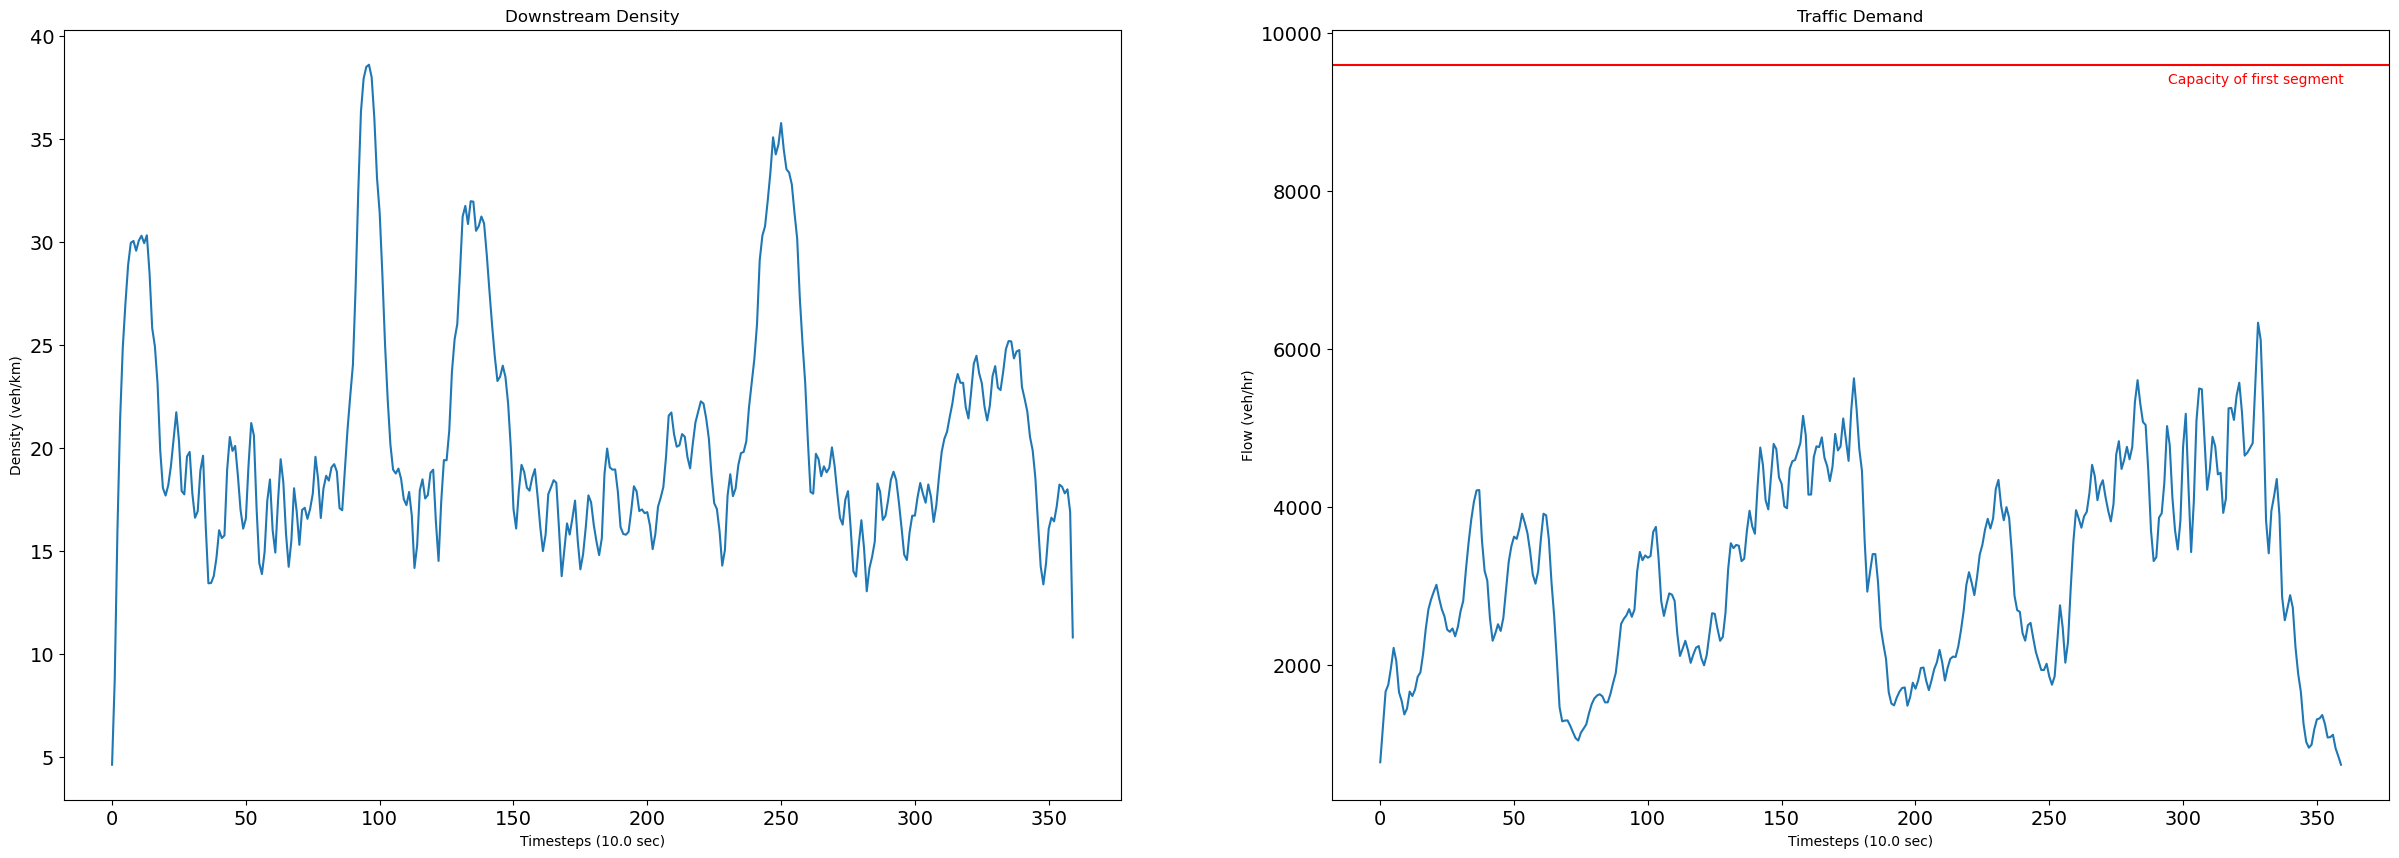

In [10]:
p = Plotter(1, 2, figsize=(30, 10))

p[0] = {'title': 'Downstream Density', 'xlabel': f'Timesteps ({time_step*3600} sec)', 'ylabel': 'Density (veh/km)'}
p[0].plot(downstream_density)

p[1] = {'title': 'Traffic Demand', 'xlabel': f'Timesteps ({time_step*3600} sec)', 'ylabel': 'Flow (veh/hr)'}
p[1].plot(data_inflow)
p[1].axhline(2400 * lane_counts[0], c='red')
p[1].text(x=len(data_inflow), y=2400 * lane_counts[0]-100, s="Capacity of first segment", va="top", ha="right", color="red")

for ax in p: ax.tick_params(axis='both', which='major', labelsize=14)

plt.show()

## Simulation of no control scenario

In [11]:
const_vsl = np.array([np.full(num_segments, np.max(model_params['v_free'])) for _ in range(time_steps)])
init_state = (true_density_initial, true_velocity_initial, data_inflow[start_time_step], 0)

p_sim, v_sim, _, tts_sim = run_metanet_sim_plottable(
                                T=time_step, # 10 sec
                                l=L, # 0.4 miles
                                init_traffic_state=init_state, # (n_segments, n_segments, time_steps, 1)
                                demand=data_inflow[start_time_step:], # time_steps
                                downstream_density=downstream_density[start_time_step:], # time_steps
                                params=model_params,
                                lanes=lane_dict,
                                vsl_speeds=None,
                                real_data=True
                              )

p_sim = p_sim[0:-1, :]
v_sim = v_sim[0:-1, :]

print(p_sim.shape, v_sim.shape)
print(f"Total travel time: {tts_sim:.3f} vehicle-hours")

(360, 14) (360, 14)
Total travel time: 550.629 vehicle-hours


max_v=102.54945910649667


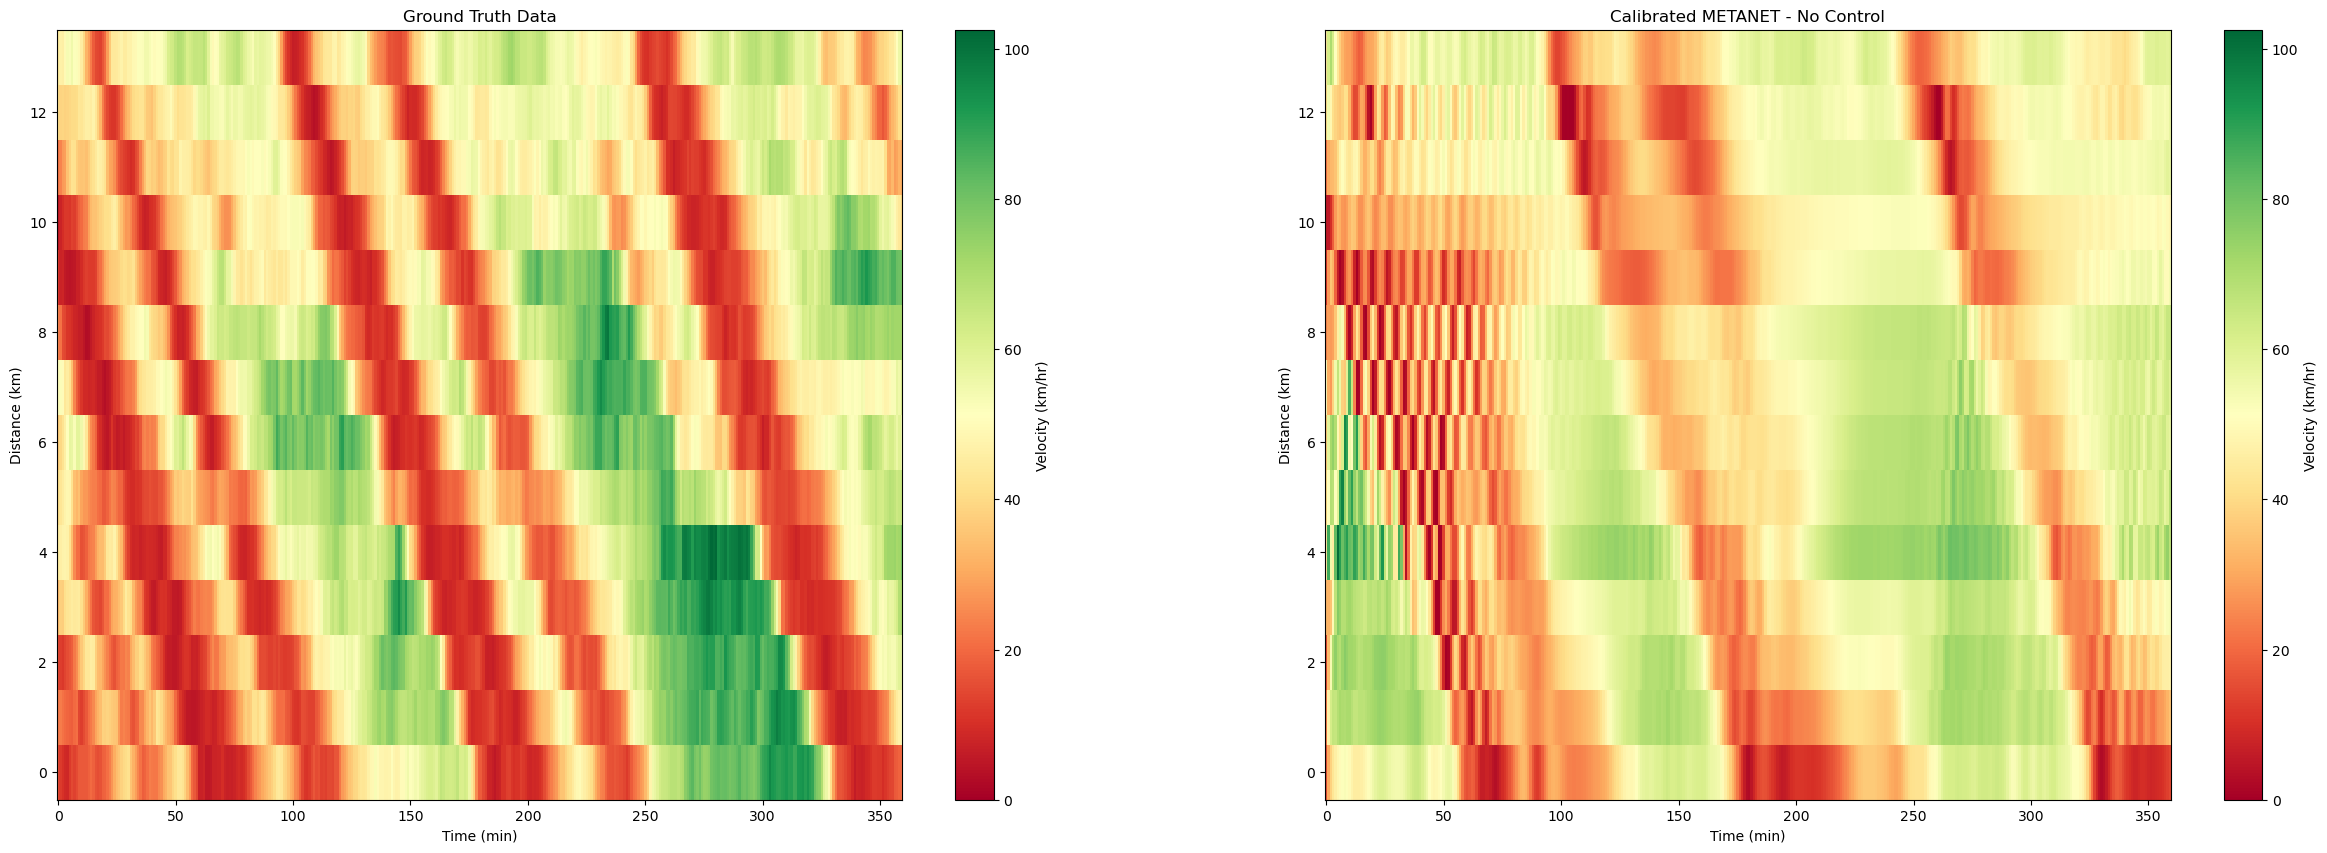

In [12]:
# Read in v_pred.npy from the path location
max_v = max(np.max(velocity_data), np.max(v_sim))
print(f"{max_v=}")

p = Plotter(1, 2, figsize=(30, 10))

for i, mat in enumerate([velocity_data, v_sim]):
  p.fig.colorbar(
    mappable=p[i].imshow(mat.T, cmap='RdYlGn', aspect='auto', interpolation='none', vmin=0, vmax=max_v),
    ax=p[i], label='Velocity (km/hr)'
  )
  p[i] = {'xlabel': 'Time (min)', 'ylabel': 'Distance (km)'}
  p[i].invert_yaxis()

p[0] = {'title': 'Ground Truth Data'}
p[1] = {'title': 'Calibrated METANET - No Control'}

plt.show()

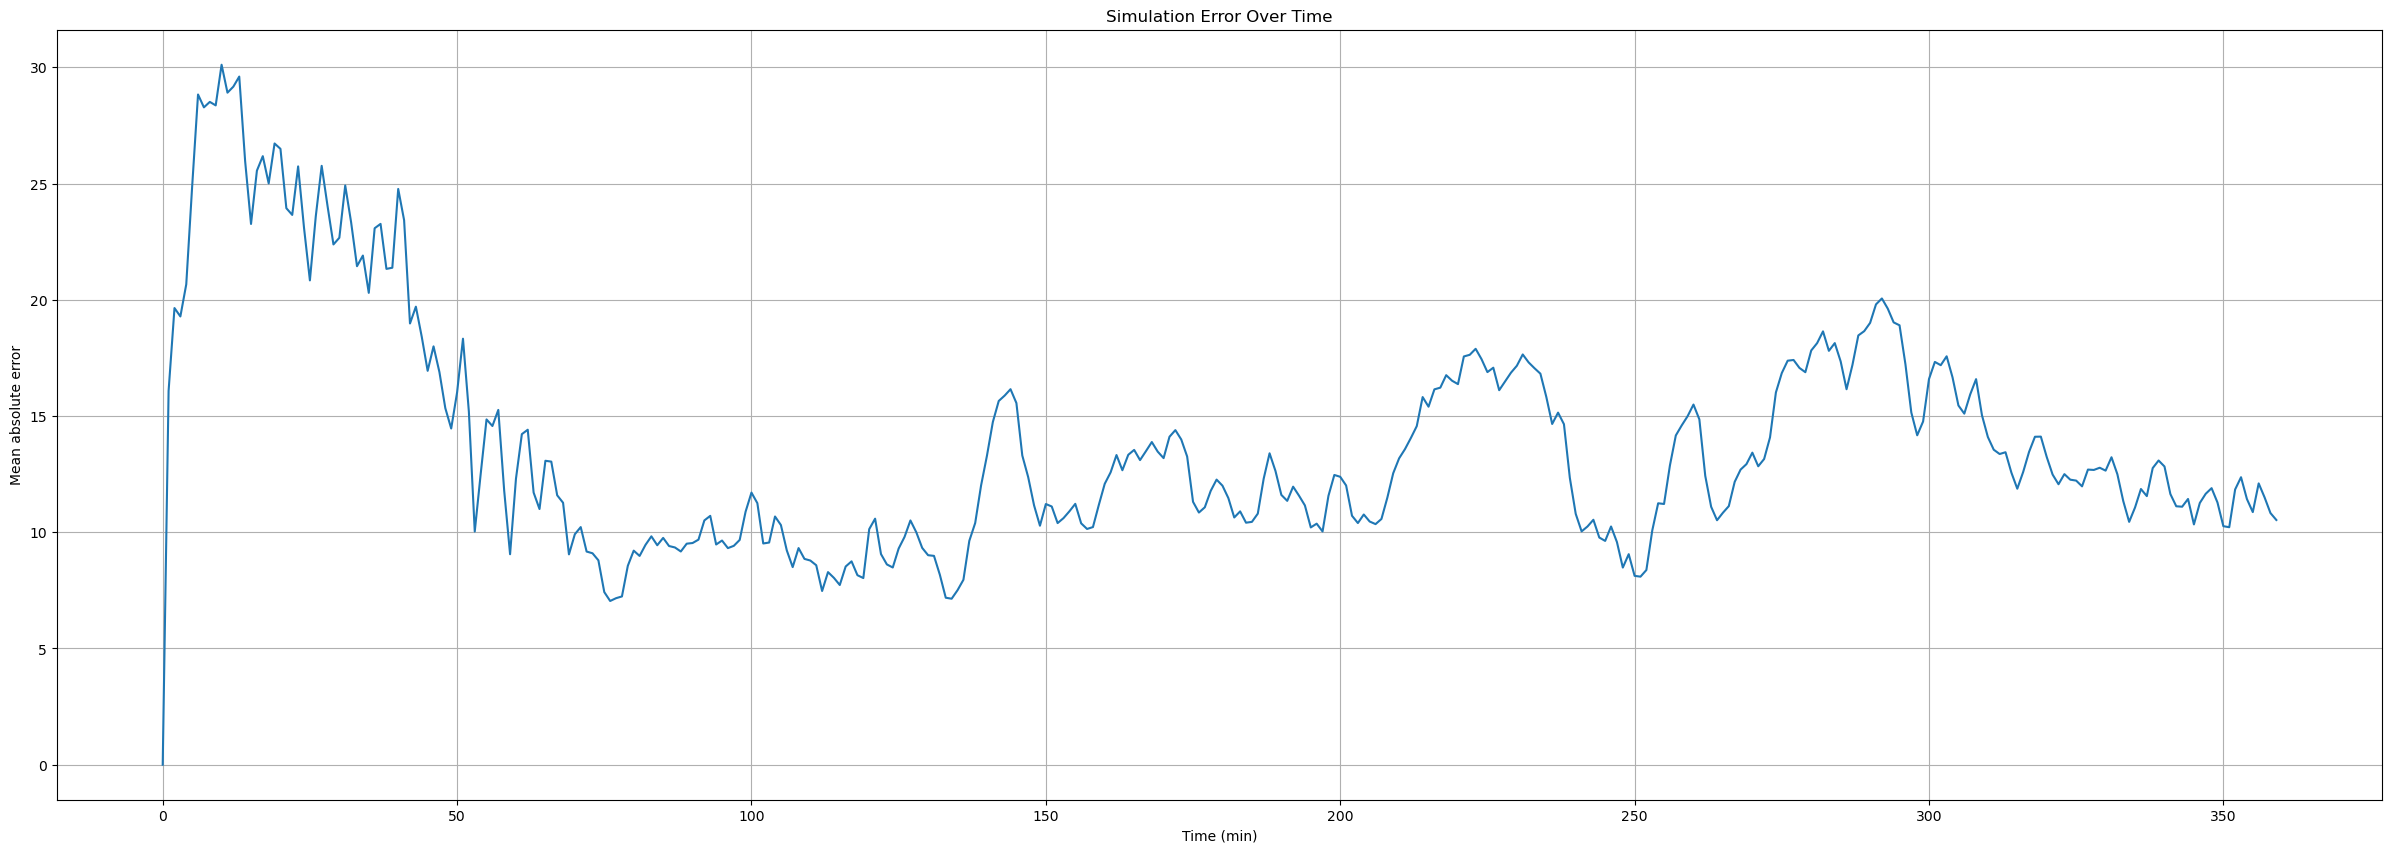

In [13]:
# plot error over time between prediction and simulation
p = Plotter(1, 1, figsize=(30, 10))
p[0].plot(np.abs(velocity_data - v_sim).mean(axis=1))
p[0] = {'xlabel': 'Time (min)', 'ylabel': 'Mean absolute error', 'title': 'Simulation Error Over Time'}
p[0].grid()
plt.show()

In [14]:
flow_sim = v_sim * p_sim * lane_counts

mape = np.mean(np.abs((velocity_data - v_sim) / velocity_data) * 100)
p_mape = np.mean(np.abs((density_data - p_sim) / density_data) * 100)
q_mape = np.mean(np.abs((flow_data - flow_sim) / flow_data) * 100)
print("Density MAPE:\t", np.round(p_mape, 2), "%")
print("Velocity MAPE:\t", np.round(mape, 2), "%")
print("Flow MAPE:\t", np.round(q_mape, 2), "%")

def rmse(y_true, y_pred): return np.sqrt(np.mean((y_true - y_pred) ** 2))

rmse_value = rmse(v_sim, velocity_data)
p_rmse_value = rmse(density_data, p_sim)
q_rmse = rmse(flow_data, flow_sim)
print("Density RMSE:\t", np.round(p_rmse_value, 2))
print("Velocity RMSE:\t", rmse_value)
print("Flow RMSE:\t", np.round(q_rmse, 2))

Density MAPE:	 33.85 %
Velocity MAPE:	 58.06 %
Flow MAPE:	 52.89 %
Density RMSE:	 9.1
Velocity RMSE:	 17.682663299911226
Flow RMSE:	 1751.24


In [15]:
# ground truth vs metanet travel time
gt_tt, metanet_tt = (time_step * L * (np.sum(rhos * lane_counts[np.newaxis,:])) for rhos in [density_data, p_sim])
print("Ground Truth Travel Time:\t", np.round(gt_tt, 2), "veh-hr")
print("Metanet Travel Time:\t\t", np.round(metanet_tt, 2), "veh-hr")
print("MAPE on total travel time:\t", np.abs(gt_tt - metanet_tt) / gt_tt * 100, "%")

Ground Truth Travel Time:	 562.15 veh-hr
Metanet Travel Time:		 549.26 veh-hr
MAPE on total travel time:	 2.2933706626236066 %


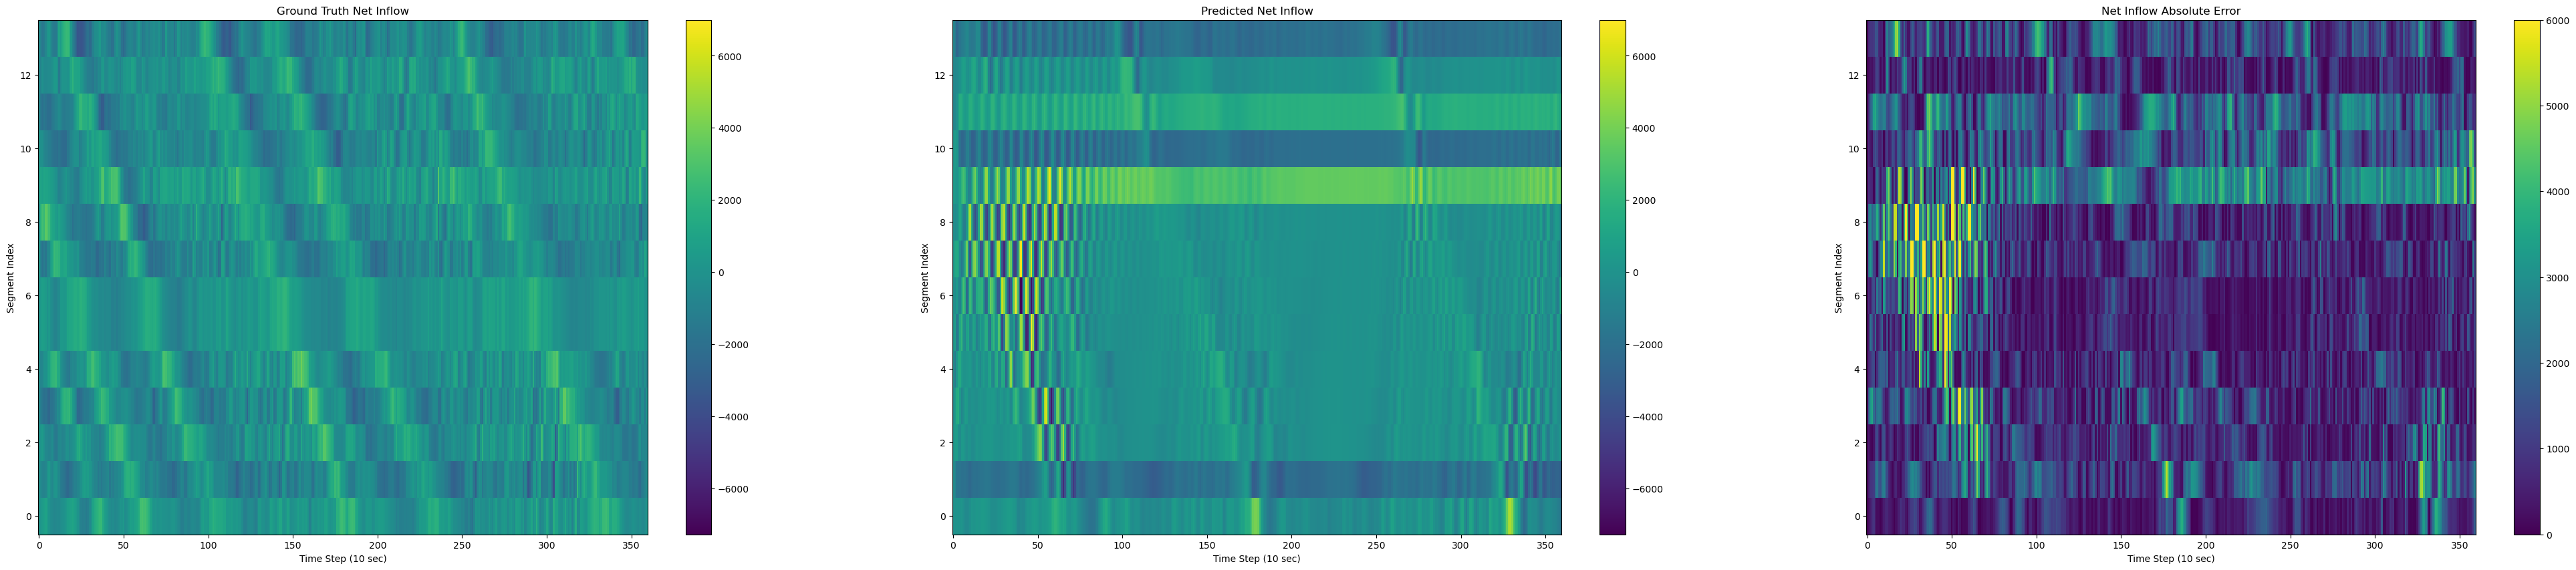

In [16]:
def get_velocity_heatmap(v_hat, v_pred, q_hat, q_pred, rho_hat, rho_pred):
    shortened_v_hat = v_hat
    shortened_rho_hat = rho_hat
    # Determine some set of 3 scalars for each of q, rho, v to make a unified map
    v_diff = np.abs(shortened_v_hat - v_pred)/shortened_v_hat
    rho_diff = np.abs(shortened_rho_hat - rho_pred)/shortened_rho_hat 
    diff = v_diff + rho_diff

    p = Plotter(2, 1, figsize=(30, 10))
    for i, (mat, cmap) in enumerate(zip([diff, shortened_v_hat], ["viridis", "RdYlGn"])):
        p.fig.colorbar(
            mappable=p[i].imshow(mat.T, cmap=cmap, aspect='auto', interpolation='none', 
                                 vmin=0 if i == 0 else None, vmax=1 if i == 0 else None),
            ax=p[i]
        )
        p[i] = {'xlabel': 'Time Step (10 sec)', 'ylabel': 'Segment Index'}
        p[i].invert_yaxis()
    p[0] = {'title': 'Combined Normalized Difference Heatmap'}
    p[1] = {'title': 'Ground Truth Velocity Heatmap'}
    plt.show()

# Calculate the error on the net_inflow
def get_net_inflow_error(q_hat: np.ndarray, q_pred: np.ndarray, highway_inflow: np.ndarray):
    # Calculate net inflow for each segment and time
    q_hat_inflow = np.hstack((highway_inflow.reshape(-1, 1), q_hat))[:, :-1]
    q_pred_inflow = np.hstack((highway_inflow.reshape(-1, 1), q_pred))[:, :-1]
    net_inflow_hat = q_hat_inflow - q_hat
    net_inflow_pred = q_pred_inflow - q_pred
    mape = np.abs(net_inflow_hat - net_inflow_pred)

    netinflow_min = min(net_inflow_hat.min(), net_inflow_pred.min())
    netinflow_max = max(net_inflow_hat.max(), net_inflow_pred.max())

    p = Plotter(1, 3, figsize=(50, 10))
    for i, mat in enumerate([net_inflow_hat, net_inflow_pred, mape]):
        p.fig.colorbar(
            mappable=p[i].imshow(mat.T, cmap='viridis', aspect='auto', interpolation='none', 
                                 vmin=netinflow_min if i < 2 else None, vmax=netinflow_max if i < 2 else 6000),
            ax=p[i]
        )
        p[i] = {'xlabel': 'Time Step (10 sec)', 'ylabel': 'Segment Index'}
        p[i].invert_yaxis()
    p[0] = {'title': 'Ground Truth Net Inflow'}
    p[1] = {'title': 'Predicted Net Inflow'}
    p[2] = {'title': 'Net Inflow Absolute Error'}
    plt.show()

get_net_inflow_error(flow_data, flow_sim, data_inflow)

TTS (VSL=130): 550.6291368406921
TTS (VSL=150): 550.6291368406921


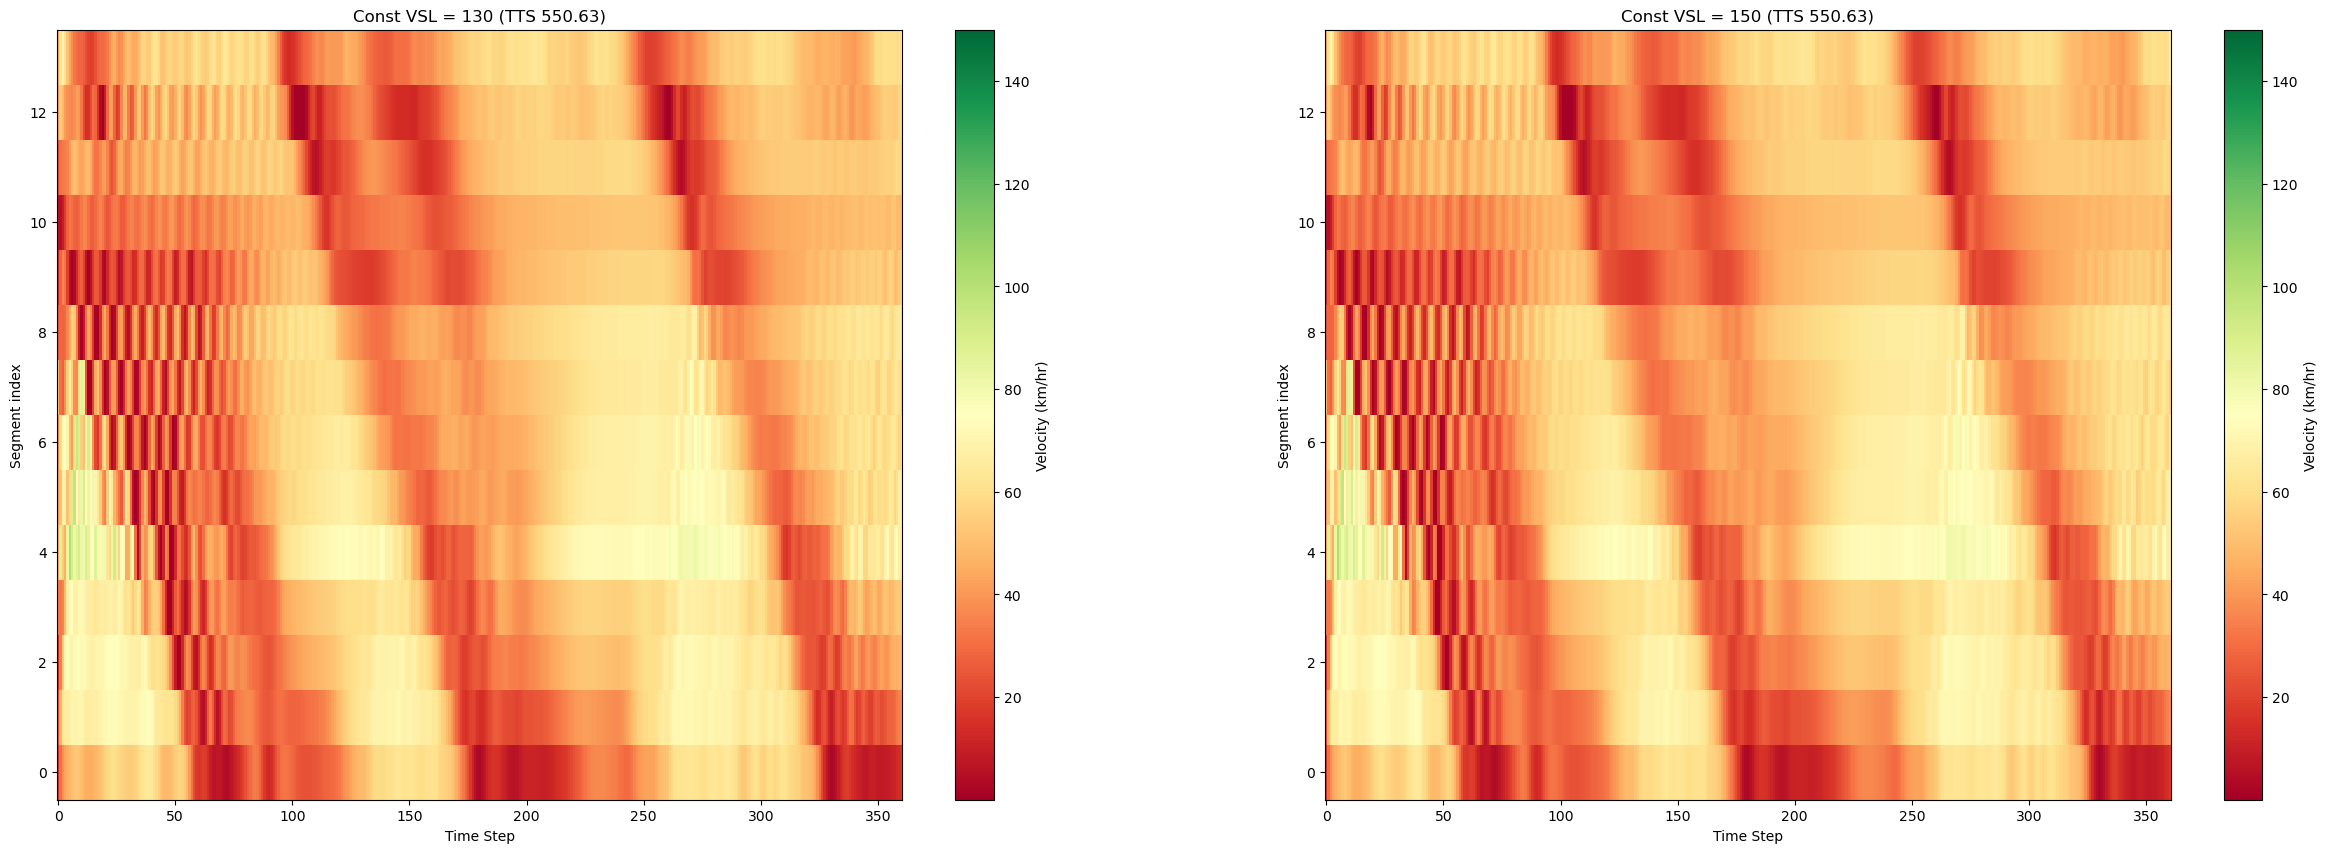

In [17]:
# simulate with constant VSL = 130 and VSL = 150, then plot side-by-side heatmaps
vsl_130 = np.ones((downstream_density.shape[0], num_segments)) * 130
vsl_150 = np.ones((downstream_density.shape[0], num_segments)) * 150

# Run simulations (turn off internal plotting to avoid duplicates)
p_130, v_130, queue_130, tts_130 = run_metanet_sim_plottable(time_step, L, init_state,
                                                   data_inflow[start_time:],
                                                   downstream_density[start_time:],
                                                   model_params,
                                                   lanes=lane_dict,
                                                   vsl_speeds=vsl_130,
                                                   real_data=False)

p_150, v_150, queue_150, tts_150 = run_metanet_sim_plottable(time_step, L, init_state,
                                                   data_inflow[start_time:],
                                                   downstream_density[start_time:],
                                                   model_params,
                                                   lanes=lane_dict,
                                                   vsl_speeds=vsl_150,
                                                   real_data=False)

print("TTS (VSL=130):", tts_130)
print("TTS (VSL=150):", tts_150)

# consistent color scale
vmin = min(np.min(velocity_data[:, 1:-1]), v_130.min(), v_150.min())
vmax = 150 #max(np.max(velocity_data[:, 1:-1]), v_130.max(), v_150.max())

p = Plotter(1, 2, figsize=(30, 10))
for i, (v_mat, sl, tts) in enumerate(zip([v_130, v_150], [130, 150], [tts_130, tts_150])):
  p.fig.colorbar(
      mappable=p[i].imshow(v_mat.T, cmap='RdYlGn', aspect='auto', interpolation='none', vmin=vmin, vmax=vmax),
      ax=p[i], label='Velocity (km/hr)'
  )
  p[i] = {'title': f'Const VSL = {sl} (TTS {np.round(tts, 2)})', 'xlabel': 'Time Step', 'ylabel': 'Segment index'}
  p[i].invert_yaxis()
plt.show()


## Optimize speed limits for controllable congestion

In [18]:
pred_horizon = 45  # in time steps
control_horizon = 5 # in time steps
hold_len = 1

opt_horizon = time_steps + pred_horizon - control_horizon
downstream_density_mpc = np.append(downstream_density, downstream_density[-1])
inflow_mpc = np.append(data_inflow, data_inflow[-1])
while len(downstream_density_mpc) <= opt_horizon + 1:
    downstream_density_mpc = np.append(downstream_density_mpc, downstream_density[-1])
    inflow_mpc = np.append(inflow_mpc, data_inflow[-1])

print(data_inflow.shape, downstream_density.shape)
print(downstream_density_mpc.shape, inflow_mpc.shape, time_steps)

(360,) (360,)
(402,) (402,) 360


In [19]:
init_state = (true_density_initial, true_velocity_initial, data_inflow[start_time], 0)

In [20]:
for k, v in model_params.items():
    if isinstance(v, np.ndarray) and v.ndim == 2:
        print(k, v.shape, "sliced!" if v.shape[0] == time_steps else "NOT SLICED — passed through whole")
{k: v.shape for k, v in model_params.items()}

{'tau': (14,),
 'K': (14,),
 'eta_high': (14,),
 'p_crit': (14,),
 'v_free': (14,),
 'a': (14,),
 'q_capacity': (14,),
 'r': (14,),
 'beta': (14,),
 'gamma': (14,)}

In [21]:
import logging 
logging.getLogger('pyomo.core').setLevel(logging.ERROR)

In [22]:
# Optimize I-24 Scenario
import json
from mpc_metanet import mpc_find_vsl

init_path = f'{results_path}/optimal_vsl_92.npy'
# init_vsl = np.load(init_path)
for speed_lb in [54]:#[24, 27, 30]:
    vsl_opt_config = {
        "hold_length": hold_len,
        "control_changepoints": None,
        "safety_temporal": None,
        "safety_spatial": None,
        "speed_lb": speed_lb,
        "warmup_time": 0, 
        "control_zone": [i for i in range(2, num_segments)],
        "control_one_segment": None,
        "initialize_vsl": None,
        "init_fixed": None, #[speed_lb, 100, 120, 140, 150], #speed if speed > 0 else None,
        "tee": False,
        "pred_horizon": pred_horizon,
        "control_horizon": control_horizon
    }

    opt_horizon = time_steps + vsl_opt_config["pred_horizon"] - vsl_opt_config["control_horizon"]

    print(f"Starting optimization... ")
    optimal_vsl = mpc_find_vsl(opt_horizon, inflow_mpc[start_time:], downstream_density_mpc[start_time:], lane_dict,
                            T=time_step,l=L, num_segments=num_segments, init_state=init_state, params=model_params, verbose=True, v_fd_penalty=1e14, **vsl_opt_config)

    print(optimal_vsl.shape)

    if CONSTRAINT == "speed_lb": path_id = f"optimal_vsl_{speed_lb}"
    else: path_id = f"optimal_vsl"
    os.makedirs(results_path, exist_ok=True)
    if vsl_opt_config["initialize_vsl"] is not None:
        vsl_opt_config["initialize_vsl"] = f"loaded from file {init_path}"

    # WRITES
    np.save(f'{results_path}/{path_id}.npy', optimal_vsl)
    with open(f'{results_path}/{path_id}_config.json', "w") as file:
        json.dump(vsl_opt_config, file, indent=4)

Starting optimization... 
[MPC] t = 0
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 5
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 10
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 15
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 20
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 25
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 30
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 35
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 40
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 45
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 50
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 55
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 60
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 65
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 70
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[

In [23]:
print(model_params['v_free'])

[ 87.10210005  83.42995873  71.50486178  70.          94.17244619
  70.          89.51853108  70.          70.          95.13600776
  70.          70.         117.46739304 149.99999998]


In [24]:
# # Print ramp info
# print("Ramp info:")
# for i in range(num_segments):
#     print(f"Segment {i}: lanes={lane_dict[i]}, on-ramp={model_params['r'][i] > 0.001}, off-ramp={model_params['beta'][i] > 0.001}")

## Plotting controlled traffic scenario

550.6291368406921


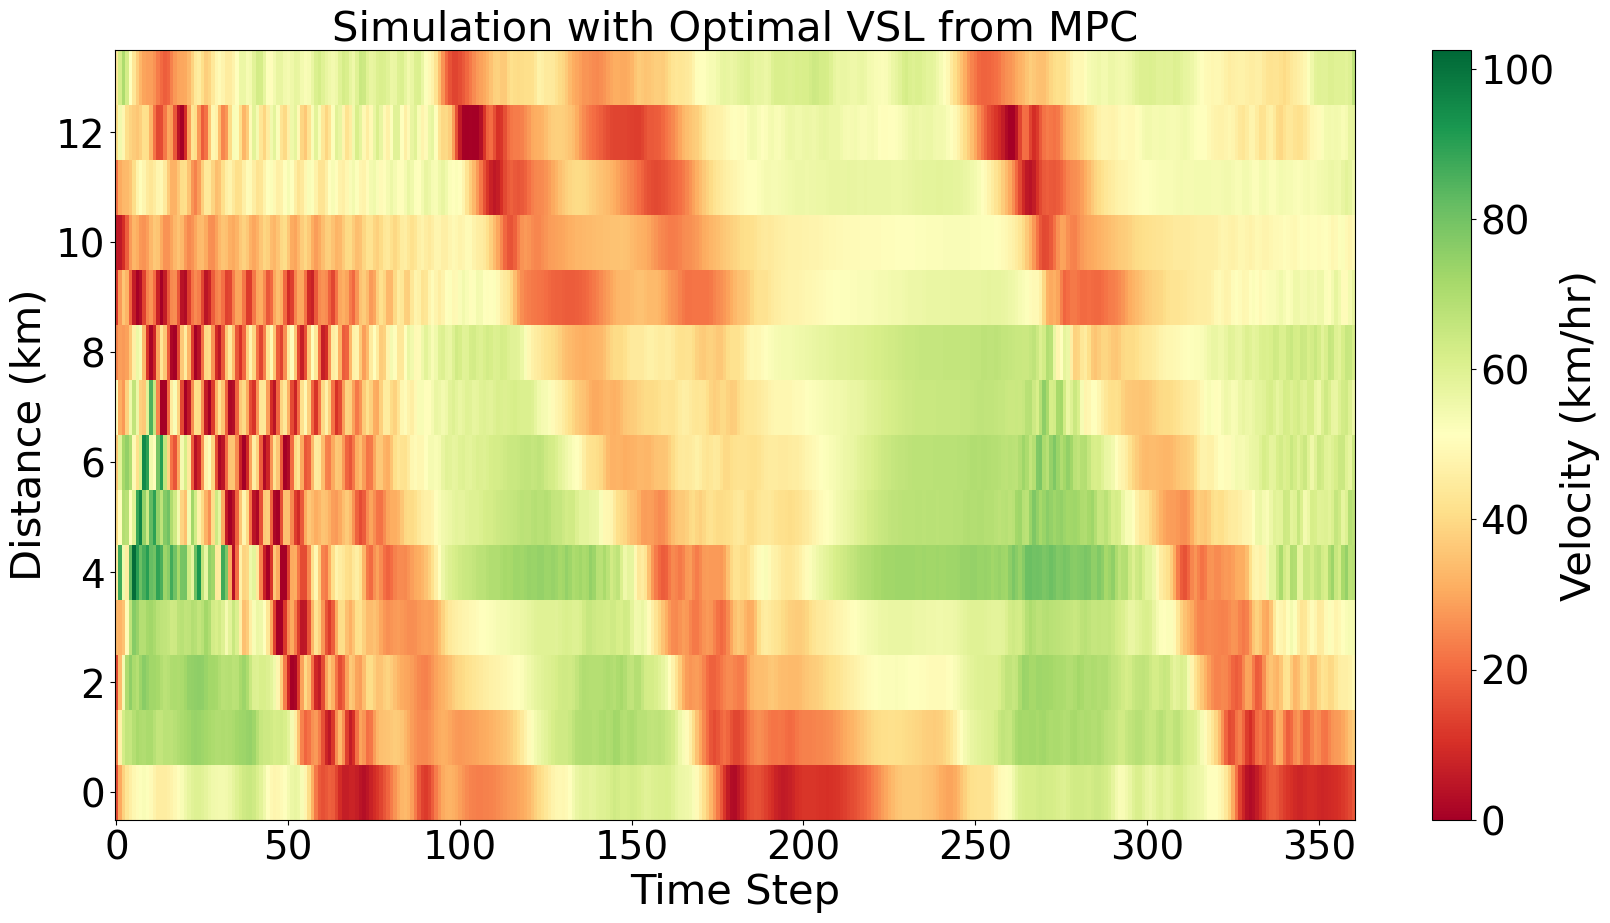

In [43]:
np.set_printoptions(suppress=True)

vsl_test = np.ones((360, num_segments)) * 150
p_baseline, v_baseline, _, tts_baseline = run_metanet_sim_plottable(time_step,
                                   L, 
                                   init_state, 
                                   data_inflow,
                                   downstream_density,
                                   model_params,
                                   lanes = lane_dict,
                                   vsl_speeds=vsl_test,
                                   real_data=False
)

print(tts_baseline)

p = Plotter(1, 1, figsize=(20, 10))
p[0] = {'title': 'Simulation with Optimal VSL from MPC', 'xlabel': 'Time Step', 'ylabel': 'Distance (km)'}
p.fig.colorbar(
  p[0].imshow(v_baseline.T, cmap='RdYlGn', aspect='auto', interpolation='none', vmin=0, vmax=np.max(velocity_data).item()),
  label='Velocity (km/hr)'
)
p[0].invert_yaxis()
plt.show()

In [44]:
print(np.min(v_baseline), np.max(v_baseline))
print(np.min(p_baseline), np.max(p_baseline))
print(model_params['v_free'].max())

0.0010000000847298907 101.27808309169065
3.4125046780403556 76.40462127287108
149.99999998193658


385.59515793198415


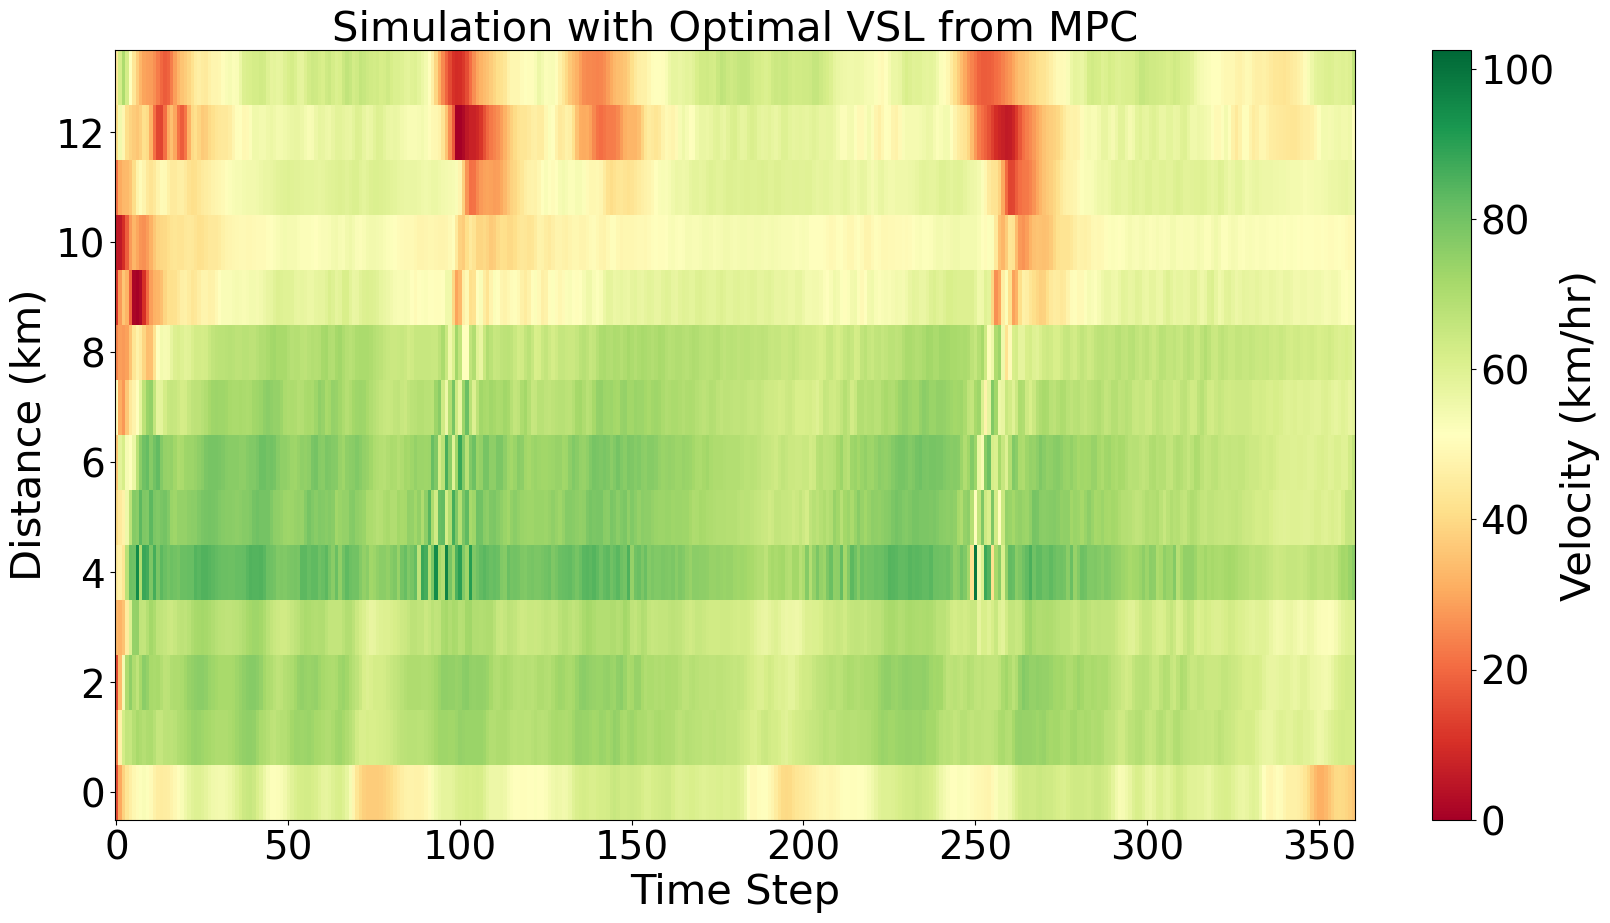

In [45]:
p_opt, v_opt, queue, tts_opt = run_metanet_sim_plottable(time_step,
                                   L, 
                                   init_state, 
                                   data_inflow,
                                   downstream_density,
                                   model_params,
                                   lanes=lane_dict,
                                   vsl_speeds=optimal_vsl,
                                   real_data=False
)

print(tts_opt)

p = Plotter(1, 1, figsize=(20, 10))
p[0] = {'title': 'Simulation with Optimal VSL from MPC', 'xlabel': 'Time Step', 'ylabel': 'Distance (km)'}
p.fig.colorbar(
  p[0].imshow(v_opt.T, cmap='RdYlGn', aspect='auto', interpolation='none', vmin=0, vmax=np.max(velocity_data).item()),
  label='Velocity (km/hr)'
)
p[0].invert_yaxis()

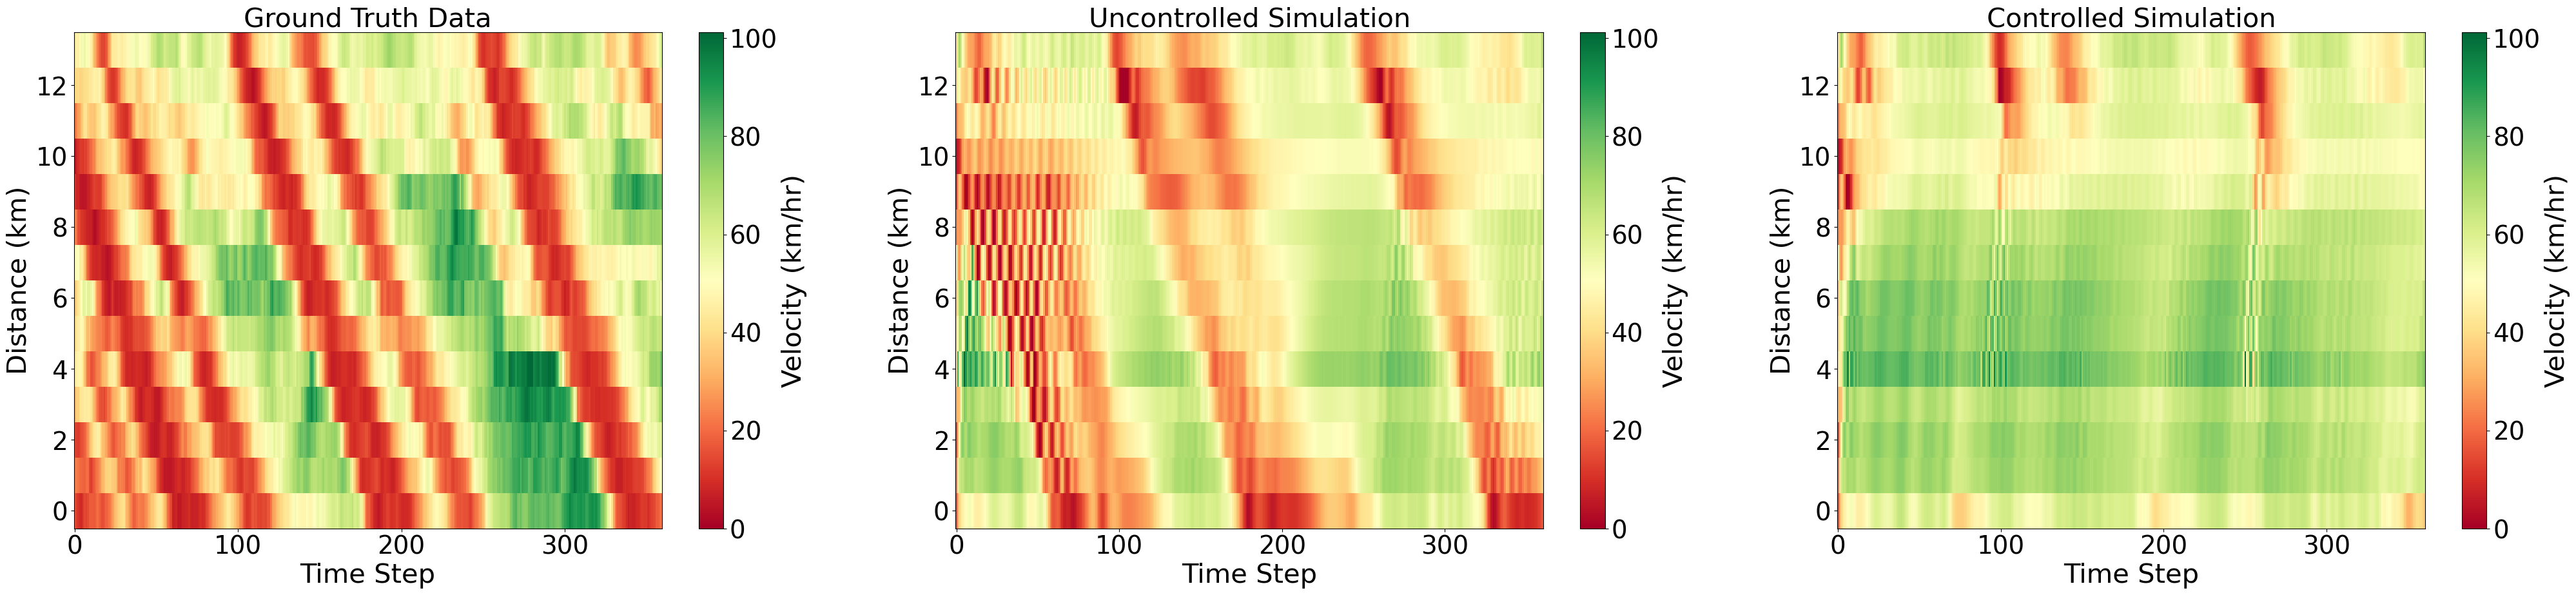

In [ ]:
# Read in v_pred.npy from the path location
max_v = max(np.max(v_baseline), np.max(v_opt))

p = Plotter(1, 3, figsize=(50, 10))
for i, mat in enumerate([velocity_data, v_baseline, v_opt]):
  p.fig.colorbar(
      mappable=p[i].imshow(mat.T, cmap='RdYlGn', aspect='auto', interpolation='none', vmin=0, vmax=max_v),
      ax=p[i], label='Velocity (km/hr)'
  )
  p[i] = {'xlabel': 'Time Step', 'ylabel': 'Distance (km)'}
  p[i].invert_yaxis()
p[0] = {'title': 'Ground Truth Data'}
p[1] = {'title': 'Uncontrolled Simulation'}
p[2] = {'title': 'Controlled Simulation'}
# plt.savefig("/Users/tristanchaang/MIT/UROP-Traffic/mpc-traffic-flow/figs/11_22_tsdiagram", dpi=150, bbox_inches='tight')

In [50]:
np.allclose(queue, 0)

True

In [30]:
print(f"TTS with VSL Control: {tts_opt} veh-hrs")
print(f"TTS with No Control: {tts_baseline} veh-hrs")

TTS with VSL Control: 385.59515793198415 veh-hrs
TTS with No Control: 550.6291368406921 veh-hrs


In [31]:
from generate_demand_synthetic import get_ff_tts

ff_ttt = get_ff_tts(data_inflow, time_step, L, model_params['v_free'])
print("Total free flow travel time:", ff_ttt, "veh-hrs")
delay  = tts_baseline - ff_ttt
opt_delay = tts_opt - ff_ttt
cc = (delay - opt_delay) / delay * 100
print(f"Controllable congestion: {cc}%")

Total free flow travel time: 214.24253450454228 veh-hrs
Controllable congestion: 49.06080615653954%


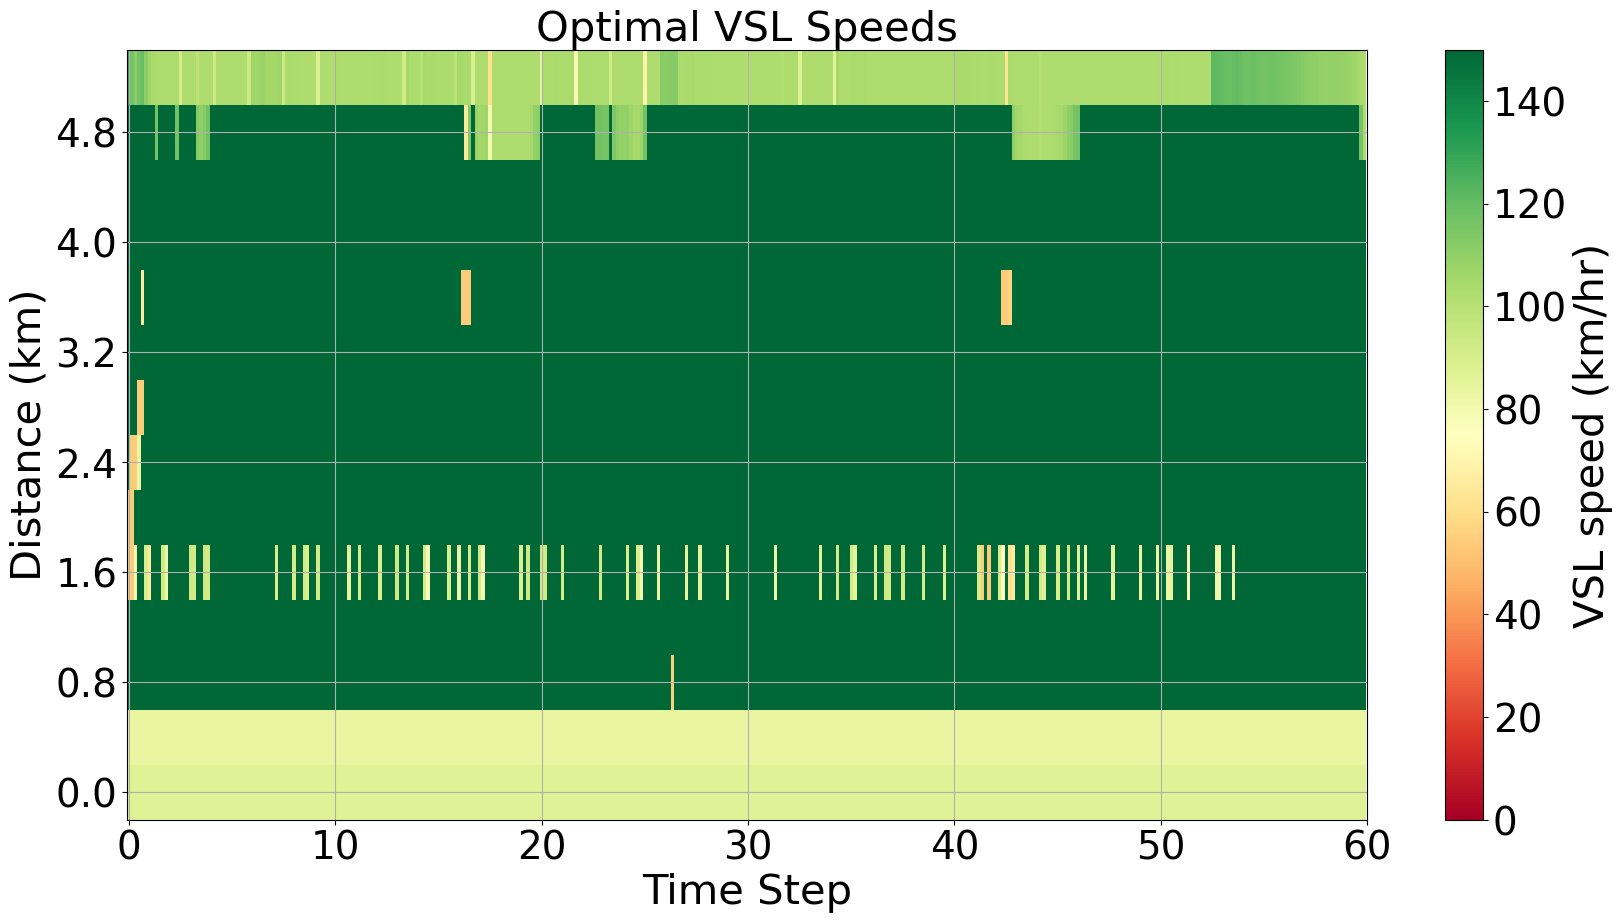

In [53]:
from plotting import plot_vsls
optimal_vsl = np.load(f'{results_path}/optimal_vsl_54.npy')
v_free_extended = np.tile(model_params['v_free'], (optimal_vsl.shape[0], 1))
optimal_vsl = np.where(optimal_vsl > v_free_extended, 150, optimal_vsl)
plot_vsls(optimal_vsl, time_steps+1, num_segments, np.max(model_params['v_free']), T=time_step, l=L)

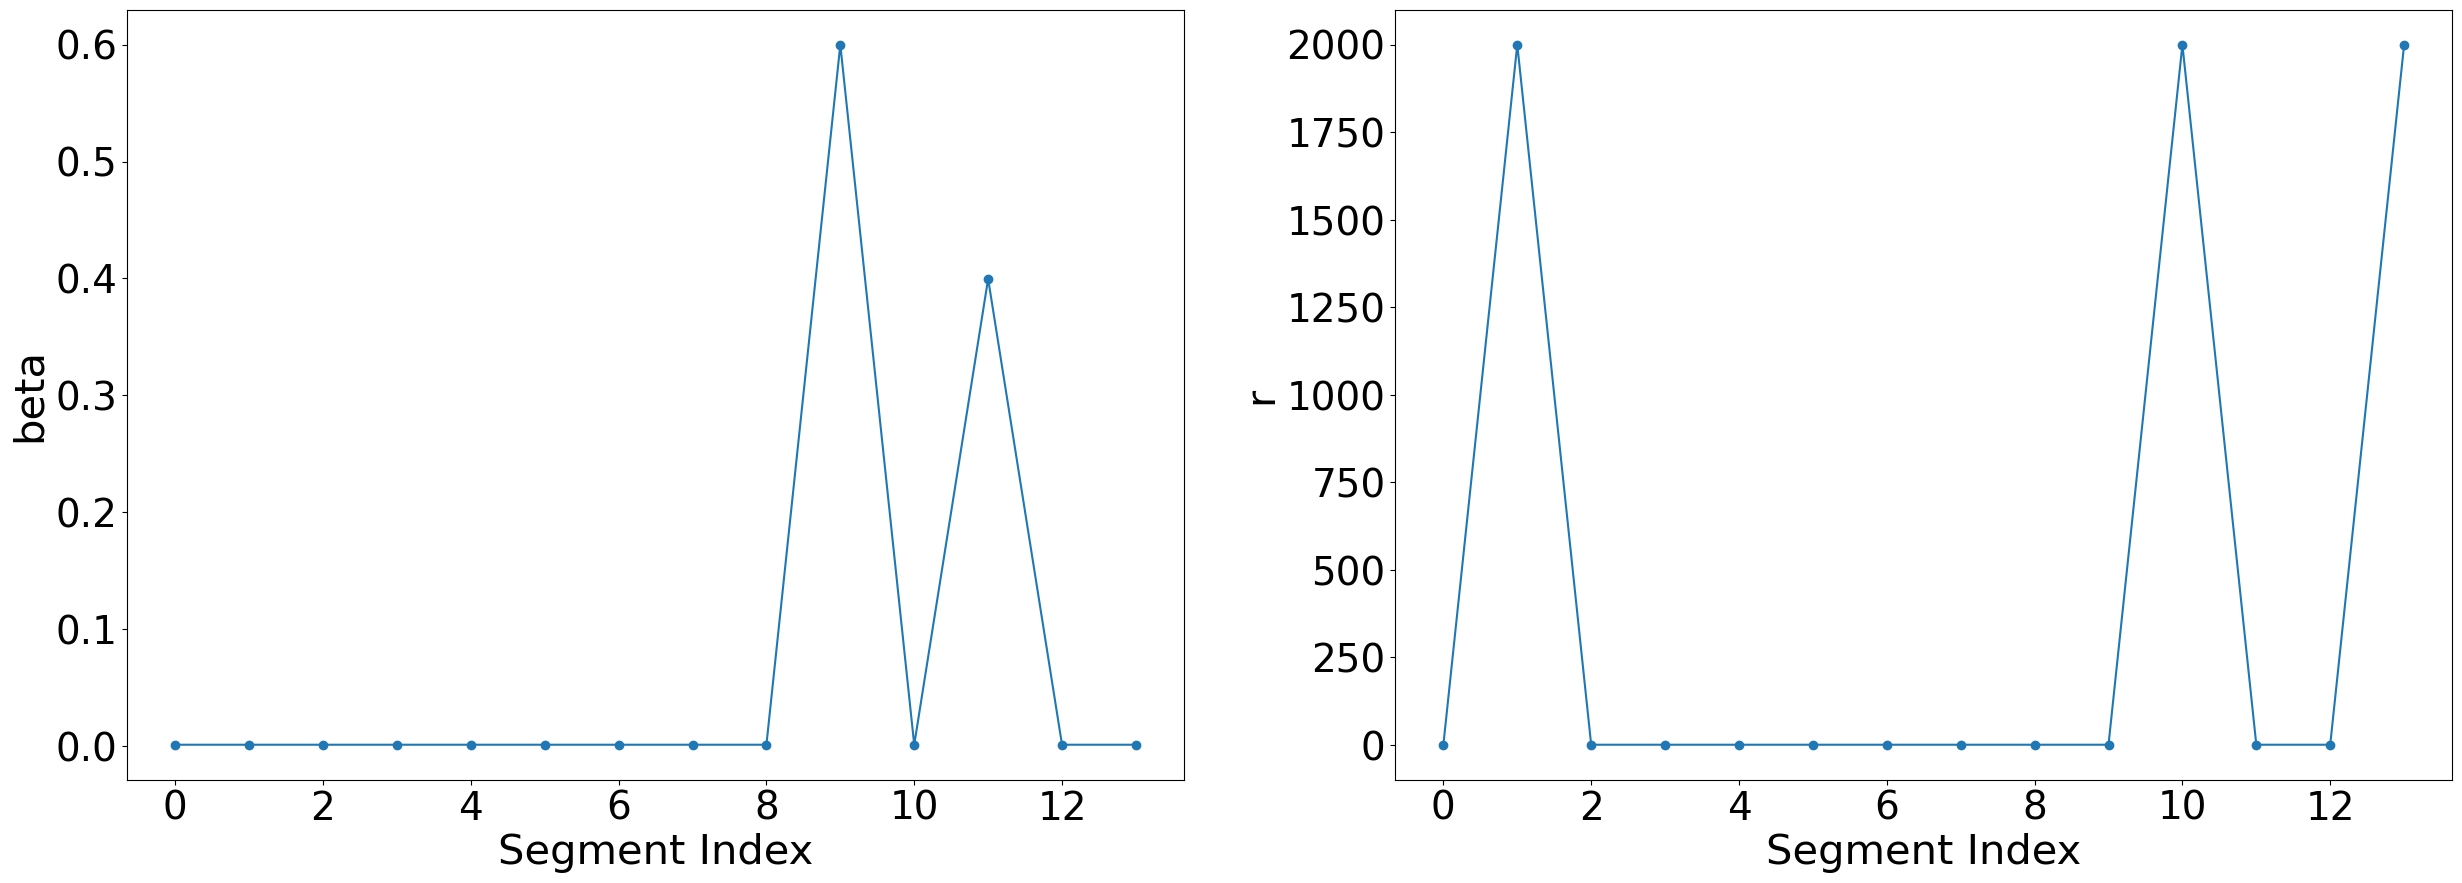

In [58]:
p = Plotter(1, 2, figsize=(30, 10))
for i, variable in enumerate(['beta', 'r']):
  p[i] = {'xlabel': 'Segment Index', 'ylabel': variable}
  p[i].plot(model_params[variable], marker='o')

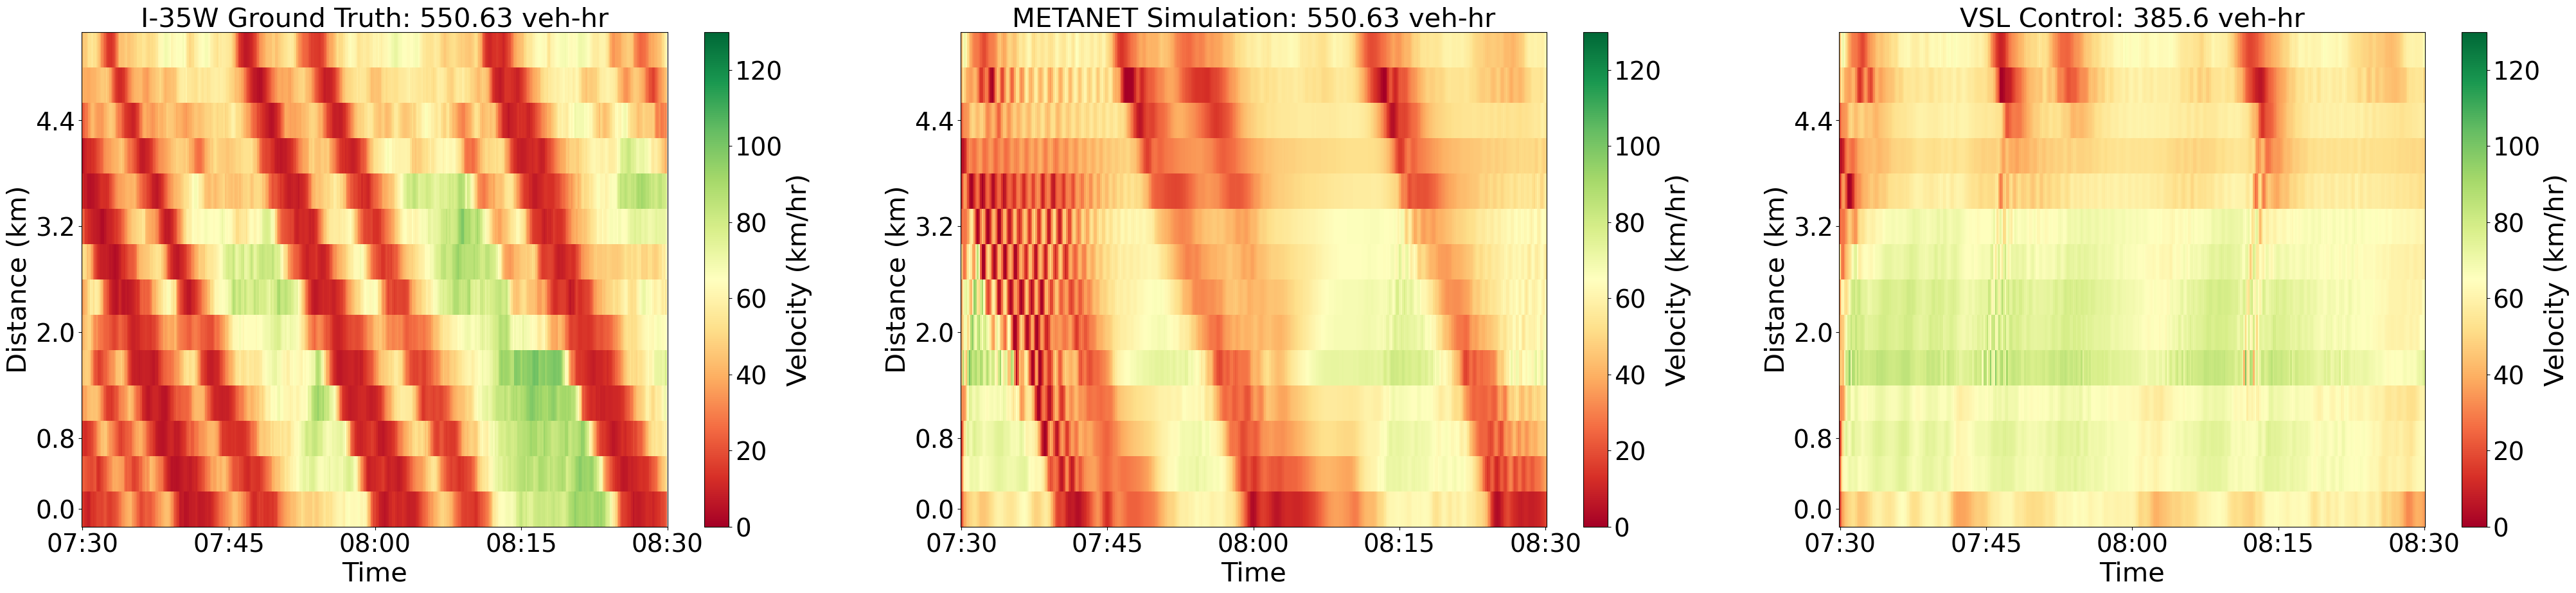

In [104]:
start_wallclock_time = 7.5
# start_wallclock_time = 7

n_time = velocity_data[:, 1:-1].shape[0] +1
minutes = np.arange(n_time) * time_step * 60
tick_pos = np.linspace(0, n_time - 1, 5, dtype=int)

def to_wallclock(tick_minutes, start_hour):
    labels = []
    for m in tick_minutes:
        total_minutes = start_hour * 60 + m
        h = int(total_minutes // 60) % 24
        mn = int(total_minutes % 60)
        labels.append(f"{h:02d}:{mn:02d}")
    return labels

tick_labels = to_wallclock(minutes[tick_pos], start_wallclock_time)

# Compute y ticks in km — add this before the imshow calls
n_segments = velocity_data[:, 1:-1].shape[1]
ytick_pos = np.linspace(0, n_segments - 1, 5, dtype=int)
ytick_labels = [f"{i * 0.4:.1f}" for i in ytick_pos]  # 400m per segment → km

p = Plotter(1, 3, figsize=(50, 10))
for i, mat in enumerate([velocity_data, v_baseline, v_opt]):
  p.fig.colorbar(
      mappable=p[i].imshow(mat.T, cmap='RdYlGn', aspect='auto', interpolation='none', vmin=0, vmax=130),
      ax=p[i], label='Velocity (km/hr)'
  )
  p[i] = {'xlabel': 'Time', 'ylabel': 'Distance (km)', 'xticks': tick_pos, 'yticks': ytick_pos, 
          'xticklabels': tick_labels, 'yticklabels': ytick_labels}
  p[i].invert_yaxis()
p[0] = {'title': 'I-35W Ground Truth: ' + str(np.round(tts_baseline, 2)) + ' veh-hr'}
p[1] = {'title': 'METANET Simulation: ' + str(np.round(tts_baseline, 2)) + ' veh-hr'}
p[2] = {'title': 'VSL Control: ' + str(np.round(tts_opt, 2)) + ' veh-hr'}

In [36]:
# pointwise delay
# --- Compute Delay ---
# free_flow_speed shape: (n_segments,) → reshape to (n_segments, 1) to broadcast over time
free_flow_speed_2d = np.array(model_params['v_free'])[:, np.newaxis]  # or .reshape(-1, 1)

delay_gt   = (0.4 / velocity_data.T - 0.4 / free_flow_speed_2d) * 60
delay_ctrl = (0.4 / v_opt[0:-1, :].T - 0.4 / free_flow_speed_2d) * 60

print(np.min(delay_gt), np.max(delay_gt))

print(delay_gt.shape, delay_ctrl.shape)

with np.errstate(divide='ignore', invalid='ignore'):
    pct_decrease = np.where(
        delay_gt > 0.01,
        (delay_gt - delay_ctrl) / delay_gt * 100,
        0
    )

print(np.max(pct_decrease), np.min(pct_decrease))

-0.10067403801637502 7.3622940475497
(14, 360) (14, 360)
464.89603224573113 -48184169.56625131


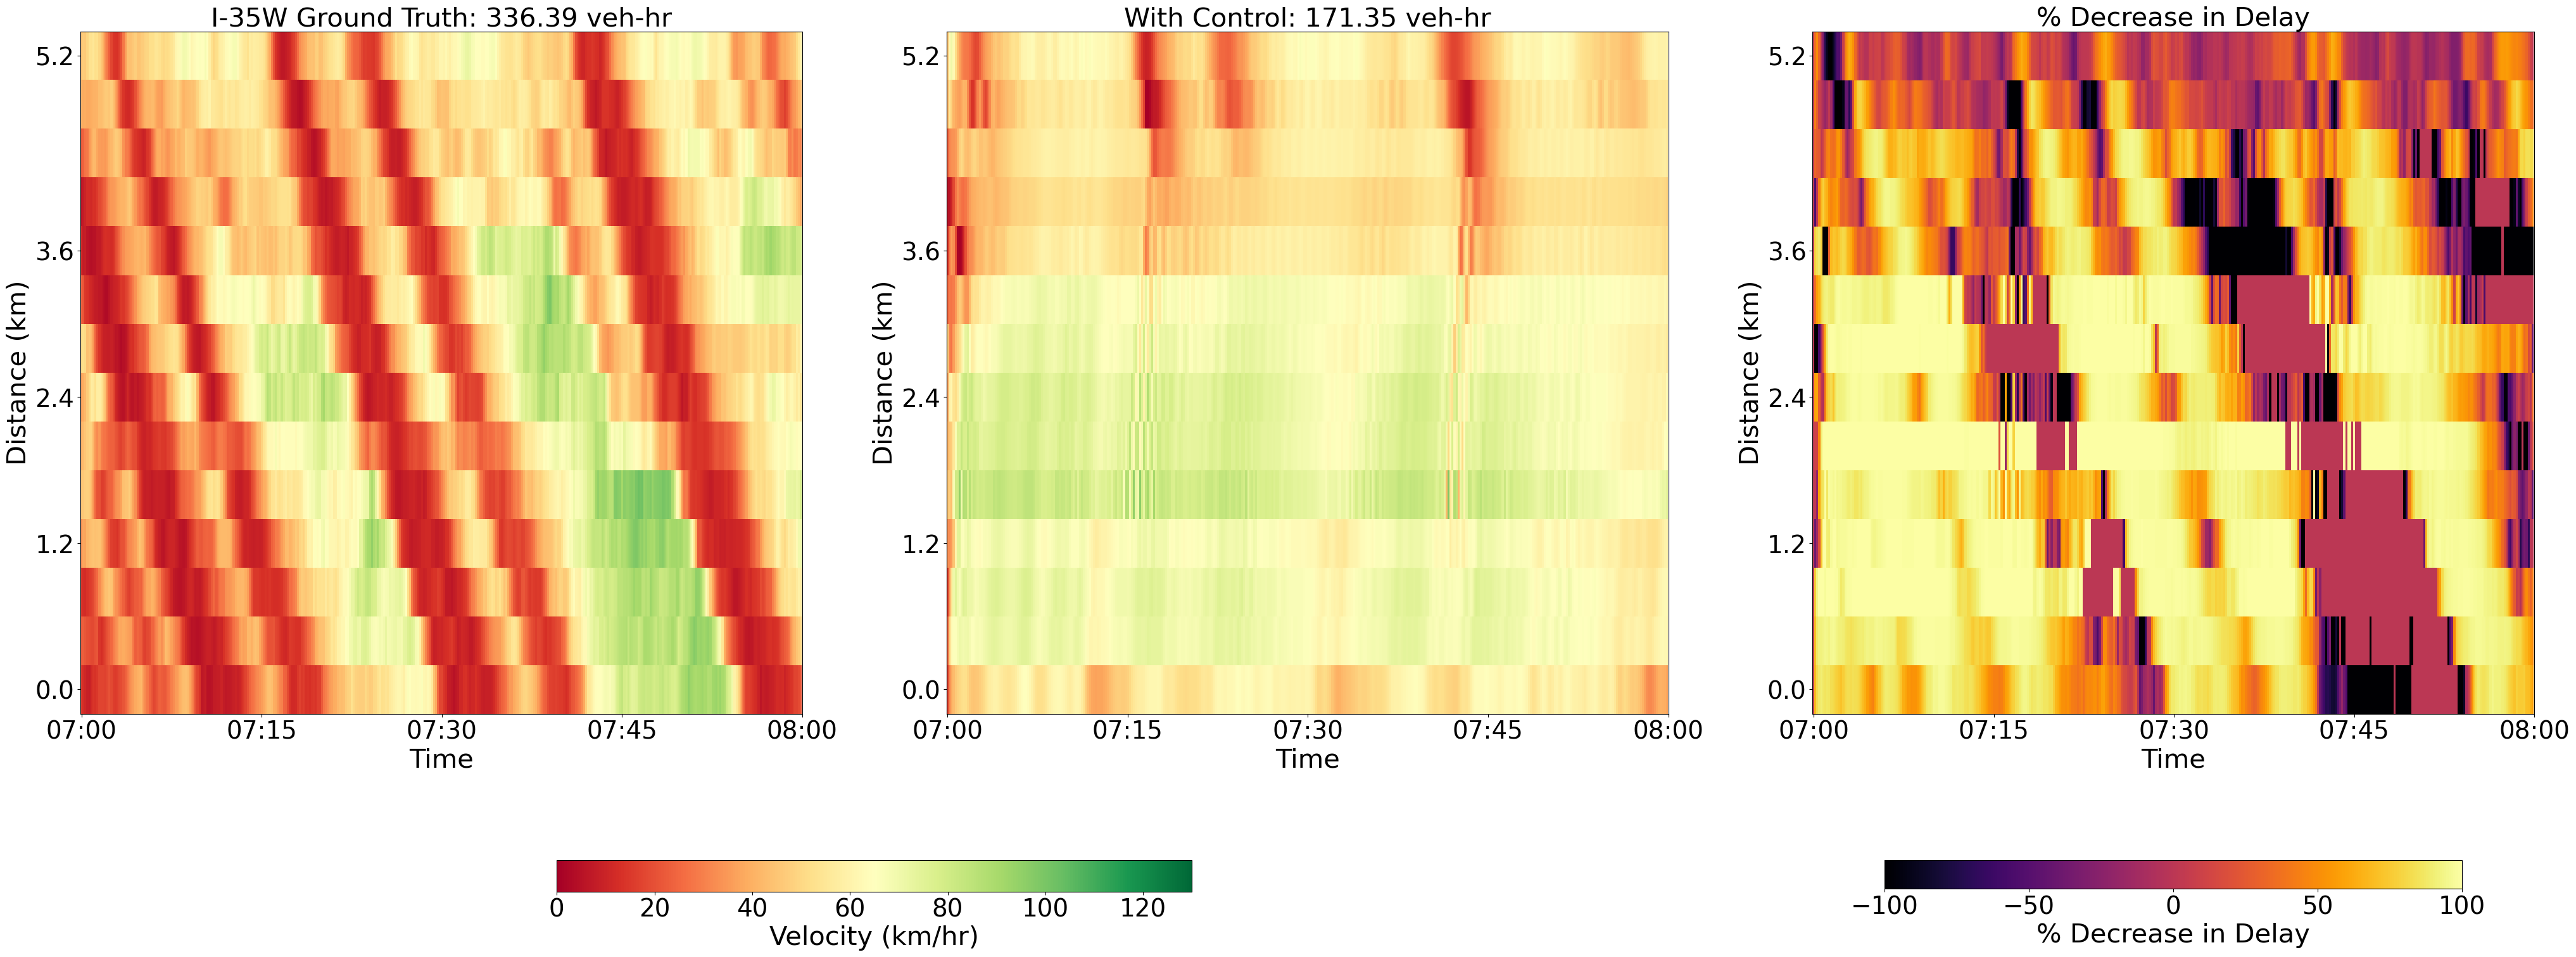

In [103]:
n_time = v_opt.shape[0]
minutes = np.arange(n_time) * time_step * 60
tick_pos = np.linspace(0, n_time - 1, 5, dtype=int)

def to_wallclock(tick_minutes, start_hour):
    labels = []
    for m in tick_minutes:
        total_minutes = start_hour * 60 + m
        h = int(total_minutes // 60) % 24
        mn = int(total_minutes % 60)
        labels.append(f"{h:02d}:{mn:02d}")
    return labels

tick_labels = to_wallclock(minutes[tick_pos], 7)

n_segments = v_opt.shape[1]
ytick_pos = np.linspace(0, n_segments-1, 5, dtype=int)
ytick_labels = [f"{i * 0.4:.1f}" for i in ytick_pos]

p = Plotter(1, 3, figsize=(50, 20))
p[0] = {'title': 'I-35W Ground Truth: ' + str(np.round(delay, 2)) + ' veh-hr'}
p[1] = {'title': 'With Control: ' + str(np.round(opt_delay, 2)) + ' veh-hr'}
p[2] = {'title': '% Decrease in Delay'}
for i, mat in enumerate([velocity_data, v_opt[0:-1, :]]):
  latest = p[i].imshow(mat.T, cmap='RdYlGn', aspect='auto', interpolation='none', vmin=0, vmax=130)
p.fig.colorbar(
    mappable=latest, 
    ax=[p[0], p[1]], label='Velocity (km/hr)', orientation='horizontal', location='bottom', pad=0.15, shrink=0.4, aspect=20
)
p.fig.colorbar(
    mappable=p[2].imshow(pct_decrease, cmap='inferno', aspect='auto', vmin=-100, vmax=100),
    ax=p[2], label='% Decrease in Delay', orientation='horizontal', location='bottom', pad=0.15, shrink=0.8, aspect=20
)
for i, ax in enumerate(p): 
    ax.invert_yaxis()
    p[i] = {'xlabel': 'Time', 'ylabel': 'Distance (km)', 'xticks': tick_pos, 'yticks': ytick_pos, 
              'xticklabels': tick_labels, 'yticklabels': ytick_labels}
plt.show()

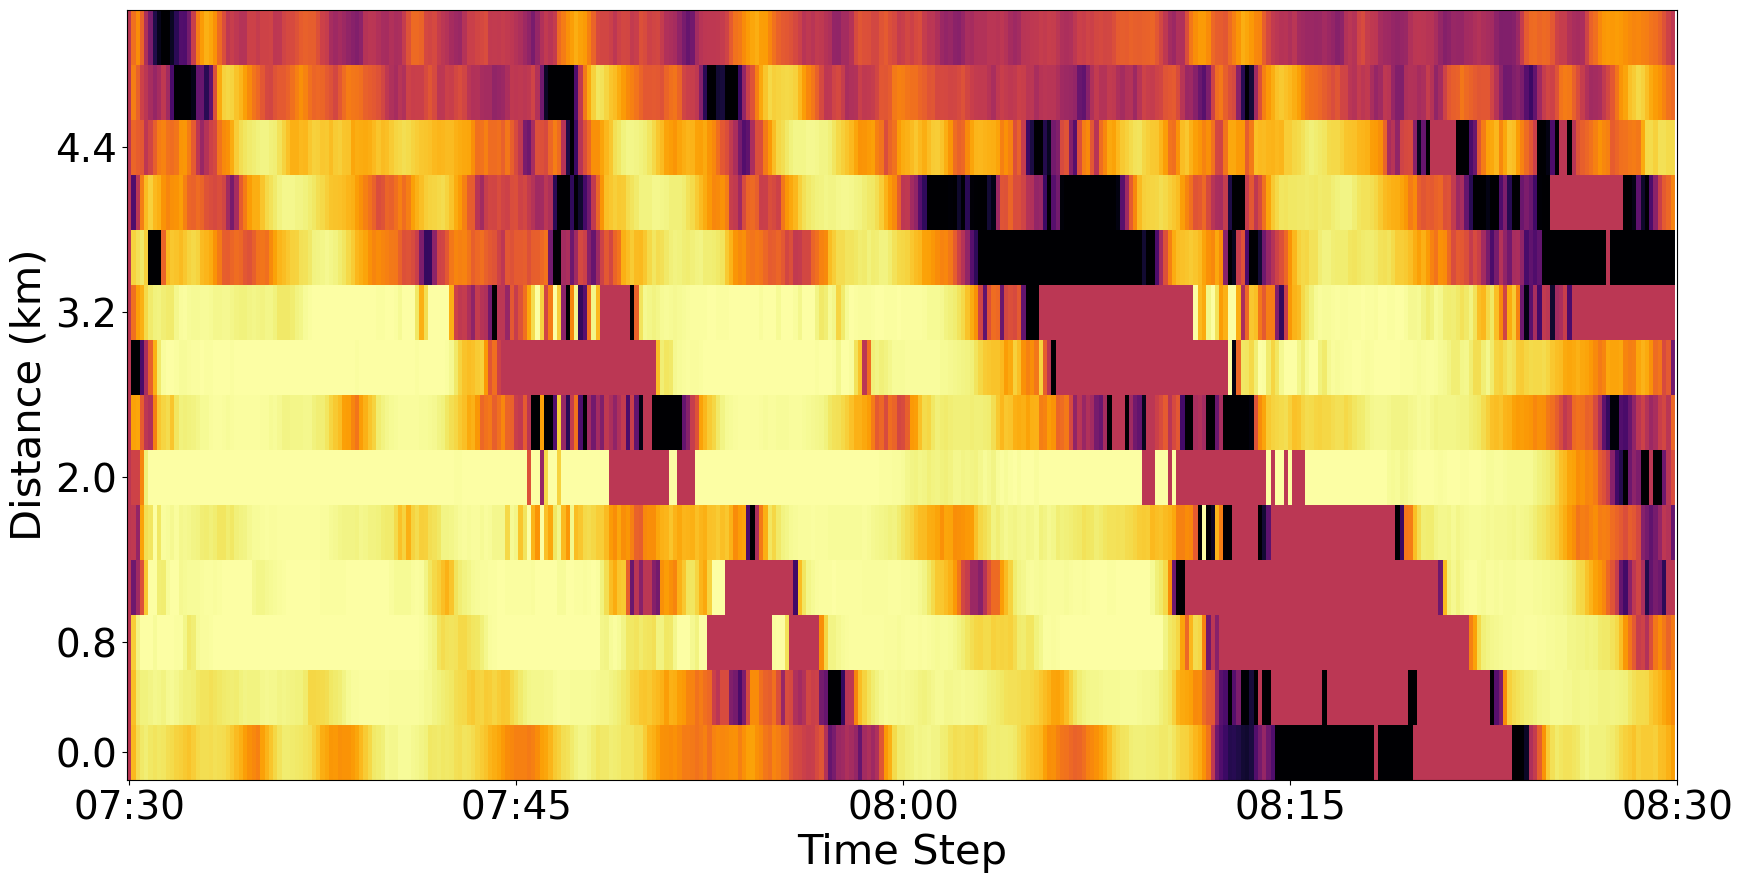

In [105]:
# Plot just the percent decrease in delay
p = Plotter(1, 1, figsize=(20, 10))

p[0].imshow(pct_decrease, cmap='inferno', aspect='auto', vmin=-100, vmax=100)
p[0].invert_yaxis()
p[0] = {'xlabel': 'Time Step', 'ylabel': 'Distance (km)', 'xticks': tick_pos, 'yticks': ytick_pos, 
          'xticklabels': tick_labels, 'yticklabels': ytick_labels}
plt.show()